# Crossreads: Petrography

This project provides tools and scripts for petrographic analysis as part of the Crossreads Project at the University of Oxford. It includes functionality for processing XRD (X-ray Diffraction) and pXRF (portable X-ray Fluorescence) data, as well as utilities for interacting with Google Sheets for data storage and retrieval.

Project structure:

- `crossreads_petrography/`: Main package directory
  - `isotopes.py`: For processing isotope data
  - `pxrf.py`: For processing pXRF data
  - `xrd.py`: For processing XRD data
  - `utils.py`: Utility functions for data handling and Google Sheets integration
- `notebooks/`: Jupyter notebooks for data analysis
- `tests/`: Unit tests
- `data/`: Directory for input and output data (not tracked in git)


## Install

Install the package directly from GitHub using pip:

In [1]:
!pip install -qU git+https://github.com/quadrismegistus/crossreads-petrography

For development or local modifications, clone the repo and install via `pip install -e ". [dev]"`.

### Configure

The project uses a flexible configuration system to manage paths and settings across different environments (local development, Google Colab, and production).

#### Setup

1. On first run, a default `config.yaml` file will be created in `~/crossreads_petrography_data/`.
2. Modify this file to adjust paths or URLs as needed for your environment.

#### Key Configuration Options

- `production`: Set to `true` for production environment, `false` for development.
- `paths`: Contains paths for various data sources and outputs.
  - Each path typically has `local` and `colab` options.
  - Some paths include `url` options for Google Sheets integration.

#### Environment-specific Behavior

- Local development: Uses local file paths by default.
- Google Colab: Automatically uses Colab-specific paths and authentication.
- Production: Can use different URLs or paths as specified in the config.

#### Google Sheets Integration

To use the Google Sheets integration:

1. For Google Colab: Authentication is handled automatically.

2. For local development: Place your Google service account credentials JSON file at:
   ```
   ~/crossreads_petrography_data/credentials.json
   ```

This path is defined in the config file as `paths.credentials.local`.

#### Further Configuration

For detailed configuration options, refer to the `config.yaml` file in your project directory. You can customize paths, URLs, and other settings to suit your specific environment and needs.

In [2]:
# for readme
from crossreads_petrography.utils import logger
logger.remove()

## Usage

### Metadata

In [3]:
from crossreads_petrography.utils import read_crossreads_spreadsheet
df_meta = read_crossreads_spreadsheet()

### Isotope Processing

The `IsotopeConverter` class in `crossreads_petrography.isotopes` handles the processing of isotope data. It performs the following tasks:

- Reads isotope curve data and sample data from Google Sheets
- Determines polygon intersections for marble types
- Generates interactive plots of isotope curves and sample points
- Saves the processed data and plots to output files

In [4]:
from crossreads_petrography.isotopes import *
isotope_converter = IsotopeConverter()
isotope_converter.run()

### pXRF Processing

The `PXRFConverter` class in `pxrf.py` handles the processing of portable X-ray Fluorescence (pXRF) data. It performs the following tasks:

- Loads pXRF standard values and descriptions
- Parses pXRF measurements
- Calculates linear regressions for standard values
- Computes adjusted element fractions based on the regressions
- Generates plots of the linear regressions
- Saves the processed data to an Excel file

In [5]:
from crossreads_petrography.pxrf import PXRFConverter
pxrf_converter = PXRFConverter()
pxrf_converter.df_standards

standard,0CC,10CC,20CC,30CC,40CC,50CC,60CC,70CC,80CC,90CC,100CC
Element,,,,,,,,,,,
Si,90.647740,84.341530,78.459710,73.463040,64.173610,55.238040,32.494610,27.119980,21.505530,11.571160,0.0
K,5.976381,5.560614,5.172827,4.843398,4.230949,3.641829,2.142361,1.788013,1.417853,0.762884,0.0
Ca,0.954312,7.844756,14.271480,19.731070,29.881110,39.644510,64.494970,70.367520,76.502120,87.356840,100.0
Fe,2.421567,2.253103,2.095976,1.962495,1.714336,1.475631,0.868062,0.724484,0.574500,0.309113,0.0


### XRD Processing

The `XRDConverter` class in `xrd.py` handles the processing of X-ray Diffraction (XRD) data. It performs the following tasks:

- Reads XRD data from input files
- Maps XRD parameters to standardized column names
- Calculates combined columns for clay minerals, K-feldspar, and plagioclase
- Updates the main CrossReads spreadsheet with processed XRD data

In [6]:
from crossreads_petrography.xrd import XRDConverter
xrd_converter = XRDConverter()
xrd_converter.run()

## Explanation

### Isotopes


In [7]:
from crossreads_petrography.isotopes import *
isotope_converter = IsotopeConverter()

#### Polygon data

The class pulls polygon data locally or from Google Drive if on Colab:

In [11]:
print(f'In Colab? {IN_COLAB}')
print(f'Isotope input data path is: {get_path("isotopes.polygons")}')

In Colab? False
Isotope input data path is: /Users/ryan/crossreads_petrography_data/data/input/isotopes


From here the sample polygons (ranged x,y values) are taken, where x is delta13C and y is delta18O:

In [ ]:
isotope_converter.df_curves

,marble_type,x,y
0,Göktepe,-3.268530,3.470874
2,Carrara,-0.170109,3.094660
4,Proconnesos-2,-9.126092,2.862408
6,Naxos,-13.932584,2.653563
7,Docimium,-11.409500,4.077670
...,...,...,...
4063,EphesosWhites1,-9.307172,3.005405
4083,EphesosWhites1,-9.144790,3.135135
4103,EphesosWhites1,-8.982409,3.254054
4123,EphesosWhites1,-8.779432,3.362162


#### Sample data

And from the crossreads spreadsheet are taken points for the same values for samples:

In [ ]:
isotope_converter.df_points

,Sample,x,y
0,ISic000104,-2.29,1.92
2,ISic000097,-1.49,3.71
3,ISic000004,-2.69,2.39
4,ISic000034,-0.71,2.56
5,ISic000036,-1.35,2.72
...,...,...,...
91,EXMFT109,-2.01,2.26
92,EXMFT112,-2.18,2.26
93,EXMFT134,-2.87,2.54
94,ICT005,-1.78,1.96


#### Intersecting samples and polygons

##### Plotting intersections

From here we can plot the samples onto the polygons:

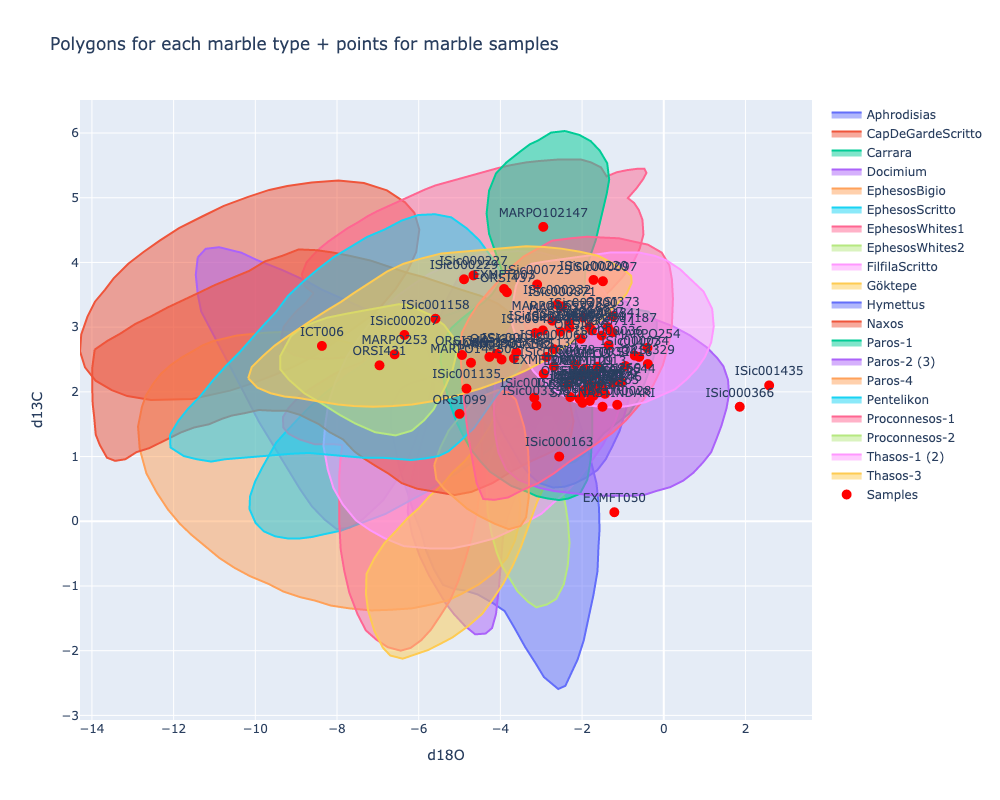

In [12]:
isotope_converter.plot(output_folder=get_path('isotopes.output'))
show_img(get_path('isotopes.output') / 'isotope_graph.png')

##### Intersection table

As well as map intersections:

In [13]:
isotope_converter.df_intersections

,Aphrodisias,CapDeGardeScritto,Carrara,Docimium,EphesosBigio,EphesosScritto,EphesosWhites1,EphesosWhites2,FilfilaScritto,Göktepe,Hymettus,Naxos,Paros-1,Paros-2 (3),Paros-4,Pentelikon,Proconnesos-1,Proconnesos-2,Thasos-1 (2),Thasos-3
nan,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️
ISic000104,✔️,,✔️,,,,,,✔️,✔️,✔️,,✔️,✔️,,,✔️,,✔️,
ISic001135,✔️,,,✔️,,✔️,✔️,,✔️,,,✔️,✔️,,,✔️,✔️,,,✔️
ISic000181,✔️,✖️,✖️,✔️,✖️,✔️,✔️,✖️,✔️,✔️,✔️,✔️,✔️,✔️,✖️,✔️,✔️,✖️,✖️,✔️
ISic000107,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
taoLastraR,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️
taoPiedi,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️
taoSarcofago,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️
taomascherome,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️,✖️
